In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_data, prepare_data, split_data
from src.preprocessing import scale_data, apply_smote, apply_pca, verify_scaling, to_torch_tensors
from src.features import compute_signal_stats
from src.models import build_svm_rbf, build_cnn_bilstm
from src.train import train_model, train_cnn_bilstm
from src.evaluate import evaluate_model, get_confusion_matrix, evaluate_torch_model, get_torch_confusion_matrix
import config

In [2]:
df = load_data(str(config.DATA_PATH))

# **I Eksplorativna analiza podataka**

# 1. Struktura podataka




In [3]:
# Oblik i prvih 5 redova

print("Oblik", df.shape)
df.head()

Oblik (11500, 180)


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


Ukupno 11500 instanci u skupu.

U skupu podataka se nalaze izmerene vrednosti EEG signala za 500 ispitanika u trajanju od 23.6 sekundi. <br> Jedna instanca skupa predstavlja izmerene vrednosti EEG signala u trajanju od jedne sekunde, <br> za jednog ispitanika, sto daje ukupno 11 500 instanci u skupu (500 x 23).

Jedna instanca u skupu podataka ima 178 atributa (vrednosti signala tokom vremena) i jednu ciljnu promenljivu (klasa), u 179. koloni tabele.

#  2. Podela na obeležja i ciljnu promenljivu

In [4]:
# Podela na features i target

X = df.drop(['y', 'Unnamed'], axis=1) # features (bez 'Unnamed')
y = df['y'] # target

print("X oblik - obeležja -", X.shape)
print("y oblik - ciljna promenljiva - ", y.shape)

X oblik - obeležja - (11500, 178)
y oblik - ciljna promenljiva -  (11500,)


# 3. Kvantitativna analiza klasa

In [5]:
print(f"Broj klasa: {y.nunique()}")
print(f"Klase: {[int(x) for x in sorted(y.unique())]}")

Broj klasa: 5
Klase: [1, 2, 3, 4, 5]


Postoji 5 klasa u skupu podataka. Podela nastaje spram različitih karakteristika EEG signala.

Klasa 1 označava moždanu aktivnost sa epileptičnim napadom, dok Klase 2-5 predstavljaju moždanu aktivnost bez napada.


In [6]:
df['y'] = df['y'].apply(lambda x: 1 if x == 1 else 0)
y = df['y']

Svodimo na dve klase:
* napad (Klasa 1, oznaka ‘1’) i
* aktivnost bez napada (Klase 2-5, oznaka ‘0’).

Broj uzoraka po binarizovanim klasama (0: Bez napada, 1: Napad):

   Broj uzoraka  Procenat (%)
y                            
0          9200          80.0
1          2300          20.0



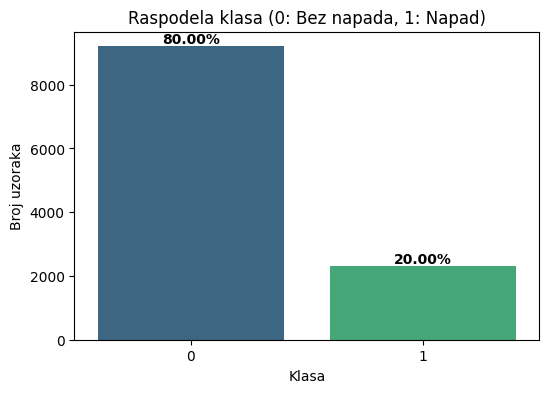

In [7]:
# Tabela i grafik

counts = y.value_counts()
percentages = y.value_counts(normalize=True) * 100

distribution_table = pd.DataFrame({
    'Broj uzoraka': counts,
    'Procenat (%)': percentages
})

print("Broj uzoraka po binarizovanim klasama (0: Bez napada, 1: Napad):\n")

print(distribution_table)

print()

plt.figure(figsize=(6, 4))
sns.barplot(x=distribution_table.index, y=distribution_table['Broj uzoraka'], palette='viridis', hue=distribution_table.index, legend=False)

plt.title('Raspodela klasa (0: Bez napada, 1: Napad)')
plt.xlabel('Klasa')
plt.ylabel('Broj uzoraka')

for i, v in enumerate(counts):
    plt.text(i, v + 100, f'{percentages[i]:.2f}%', ha='center', fontweight='bold')

plt.show()

Svođenje na binarnu klasifikaciju dovodi do **nebalansiranog skupa podataka** (jer samo jedna od 5 klasa predstavlja napad).

### 3.1. Grafik signala po klasama

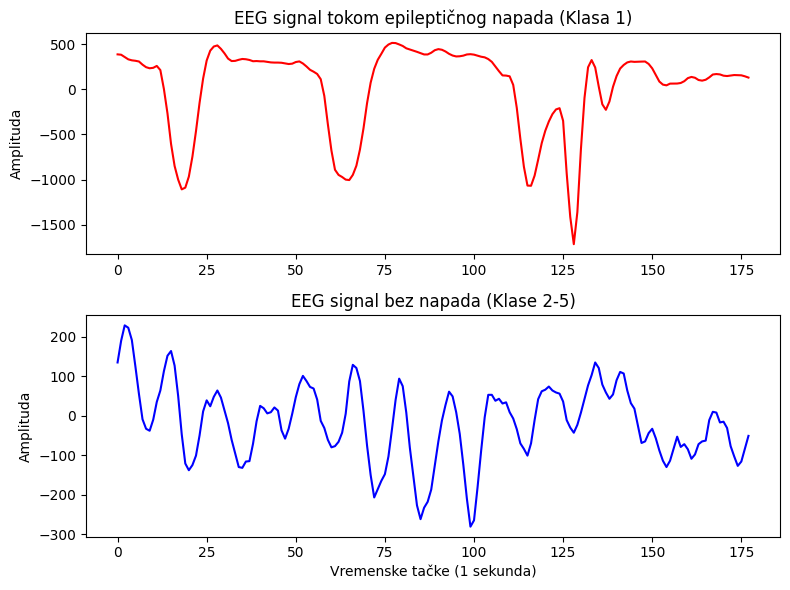

In [8]:
# Grafik signala po klasama

# Biramo po jedan primer za svaku situaciju
napad = df[df['y'] == 1].iloc[0, 1:179] # Prvi red gde je napad
bez_napada = df[df['y'] == 0].iloc[0, 1:179] # Prvi red gde nije napad

# Crtanje grafikona
plt.figure(figsize=(8, 6))

# Prvi podgrafik - Napad
plt.subplot(2, 1, 1)
plt.plot(napad.values, color='red')
plt.title('EEG signal tokom epileptičnog napada (Klasa 1)')
plt.ylabel('Amplituda')

# Drugi podgrafik - Bez napada
plt.subplot(2, 1, 2)
plt.plot(bez_napada.values, color='blue')
plt.title('EEG signal bez napada (Klase 2-5)')
plt.xlabel('Vremenske tačke (1 sekunda)')
plt.ylabel('Amplituda')

plt.tight_layout()
plt.show()


# 4. Statistička analiza

### 4.1 Standardna devijacija i varijansa signala po klasama

In [9]:
# Analiza std i var

signal_stats = compute_signal_stats(X, y)
table = signal_stats.groupby("class")[["std", "var"]].agg(["mean", "median", "min", "max"])
table.columns = ["_".join(col) for col in table.columns]
table = table.round(2)
print(table)

       std_mean  std_median  std_min  std_max   var_mean  var_median  var_min  \
class                                                                           
0         51.53       44.94    10.71   541.48    3828.04     2019.25   114.77   
1        303.47      277.41    51.50   810.40  115518.15    76958.39  2651.94   

         var_max  
class             
0      293205.20  
1      656749.44  


Uočavamo veću standardnu devijaciju kod klase '1' (napad).

# 5. Nedostajuće vrednosti

In [10]:
# Nedostajuće vrednosti

print("Zbir nedostajućih vrednosti u svakoj koloni:\n")
df.isna().sum()

Zbir nedostajućih vrednosti u svakoj koloni:



Unnamed    0
X1         0
X2         0
X3         0
X4         0
          ..
X175       0
X176       0
X177       0
X178       0
y          0
Length: 180, dtype: int64

Zaključak: Nema nedostajućih vrednosti.

# 6. Analiza netipičnih vrednosti

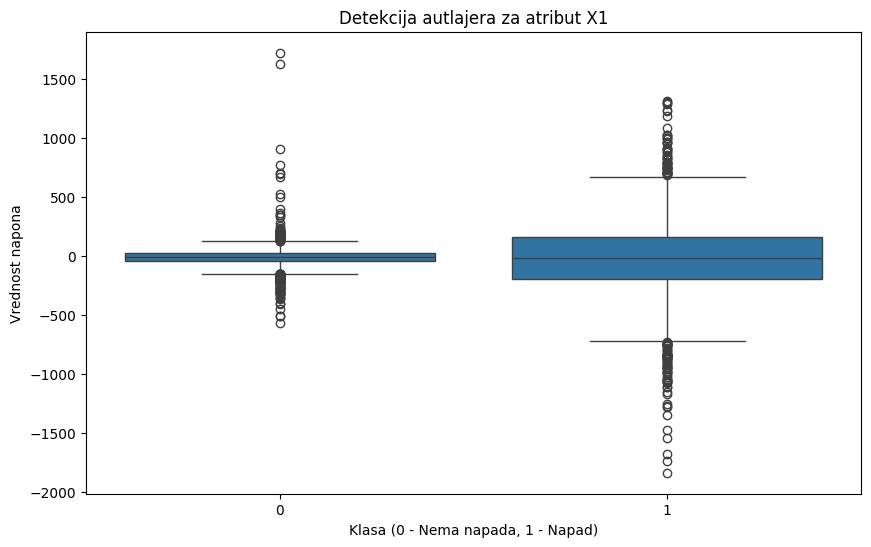

In [11]:
# Outliers

# Automatski uzimamo ime druge kolone (obično je to X1)
ime_kolone = df.columns[1]

plt.figure(figsize=(10, 6))
sns.boxplot(x='y', y=ime_kolone, data=df)

plt.title(f'Detekcija autlajera za atribut {ime_kolone}')
plt.xlabel('Klasa (0 - Nema napada, 1 - Napad)')
plt.ylabel('Vrednost napona')
plt.show()


# 7. Korelaciona matrica

Biramo mali podskup instanci (npr. prvih 15 sekundi) jer bi 178x178 matrica bila nečitljiva

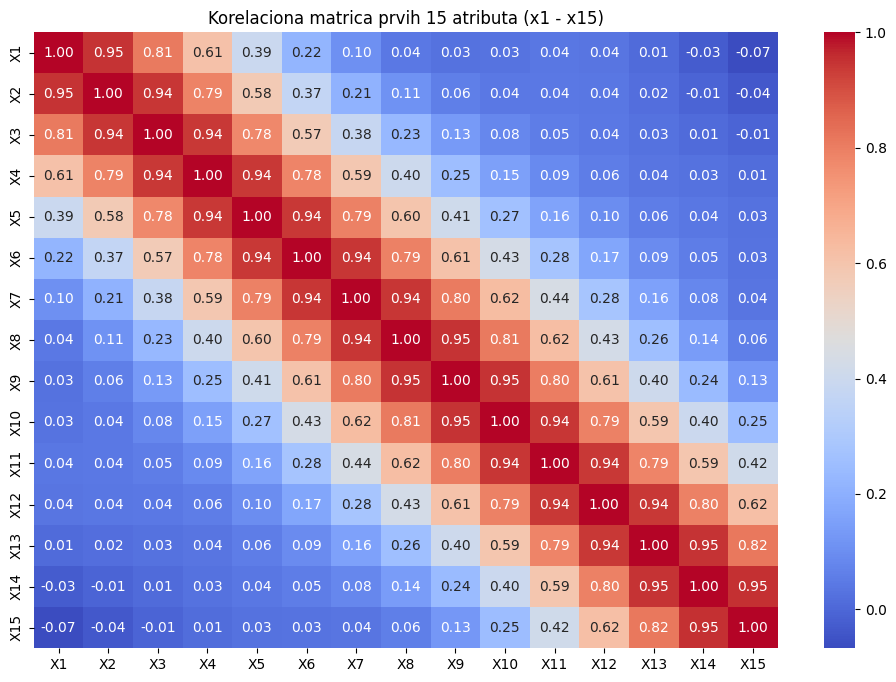

In [12]:
# Korelaciona matrica

# Biramo mali podskup kolona (npr. prvih 15 sekundi)
# jer bi 178x178 matrica bila nečitljiva
subset_columns = df.iloc[:, 1:16]

plt.figure(figsize=(12, 8))
# Računamo korelaciju
corr_matrix = subset_columns.corr()

# Crtamo toplotnu mapu (Heatmap)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Korelaciona matrica prvih 15 atributa (x1 - x15)')
plt.show()

## 7.1. Korelacione matrice po vremenskim chunkovima (15 atributa po grupi)

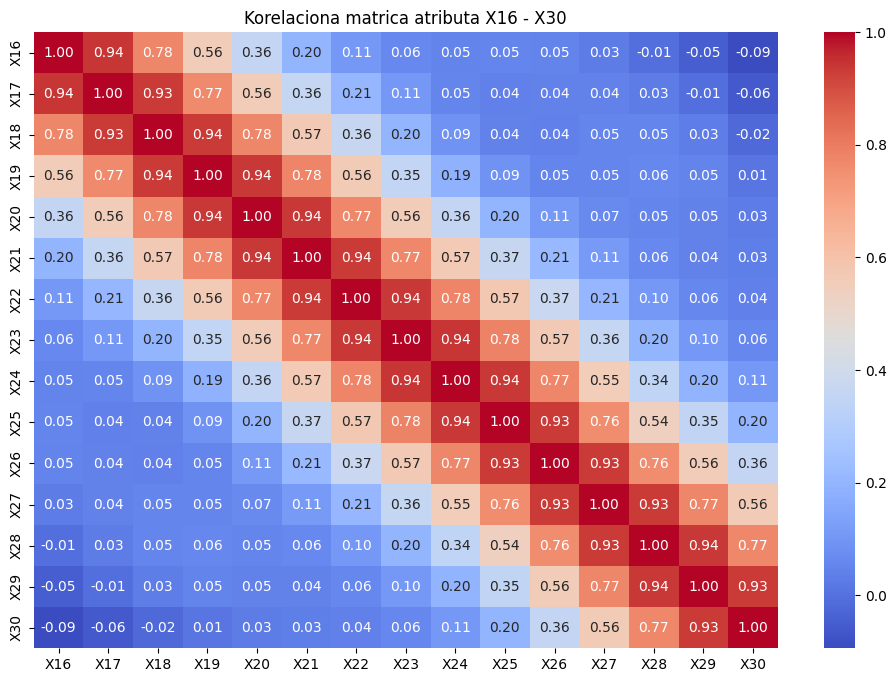

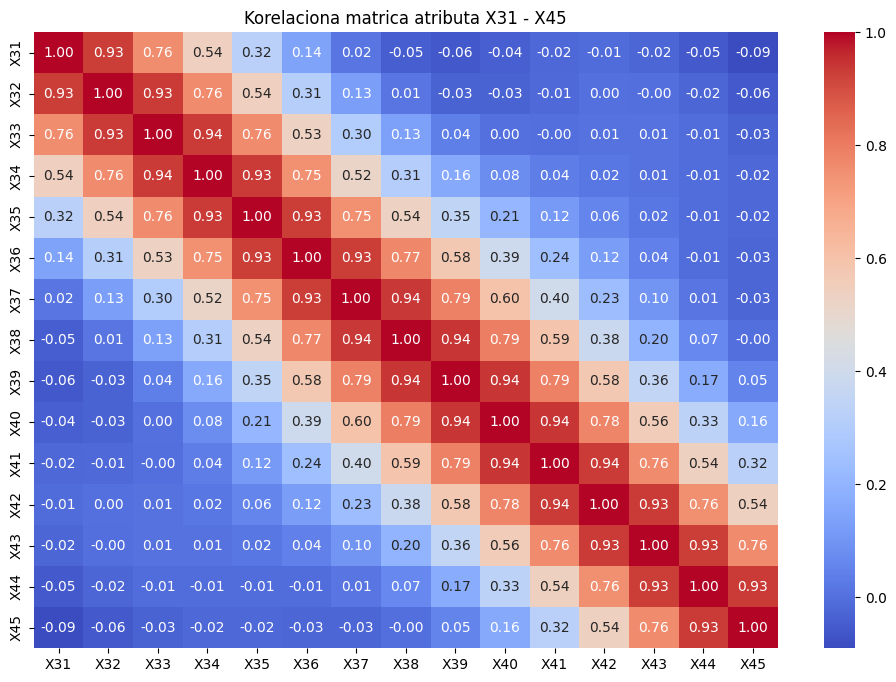

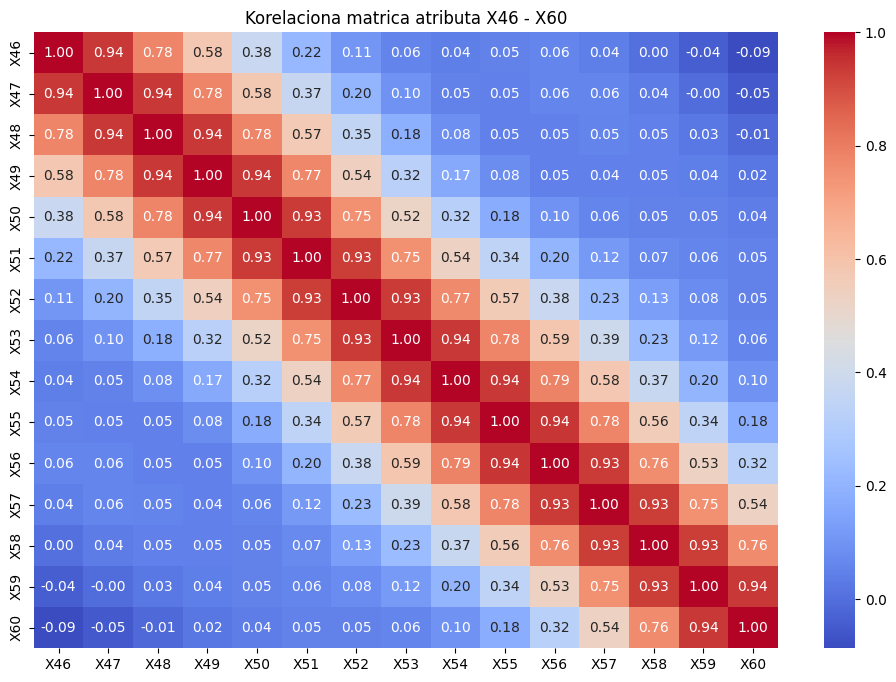

In [13]:
# Korelacione matrice za naredne grupe od po 15 atributa
# Indeksi: Unnamed=0, X1=1, X2=2, ..., X178=178, y=179

for start, end, label in [(16, 31, 'X16 - X30'), (31, 46, 'X31 - X45'), (46, 61, 'X46 - X60')]:
    subset = df.iloc[:, start:end]
    corr = subset.corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Korelaciona matrica atributa {label}')
    plt.show()

## 7.2. Korelacija obeležja sa ciljnom promenljivom

Analizirana je Pearson korelacija između pojedinačnih atributa i ciljne promenljive kako bi se identifikovali delovi EEG signala koji najviše doprinose detekciji epileptičnog napada.

Analiza Pearson korelacije između pojedinačnih atributa i ciljne promenljive pokazala je da su sve vrednosti korelacije relativno niske, u opsegu približno od -0.04 do 0.56, što ukazuje da ni jedan pojedinaćni atribut nema značajan linearni uticaj na klasifikaciju epileptičnog napada. Iz ovoga zaključujemo da je EEG nosi kompleksan set obeležja na vremenskom liniji.

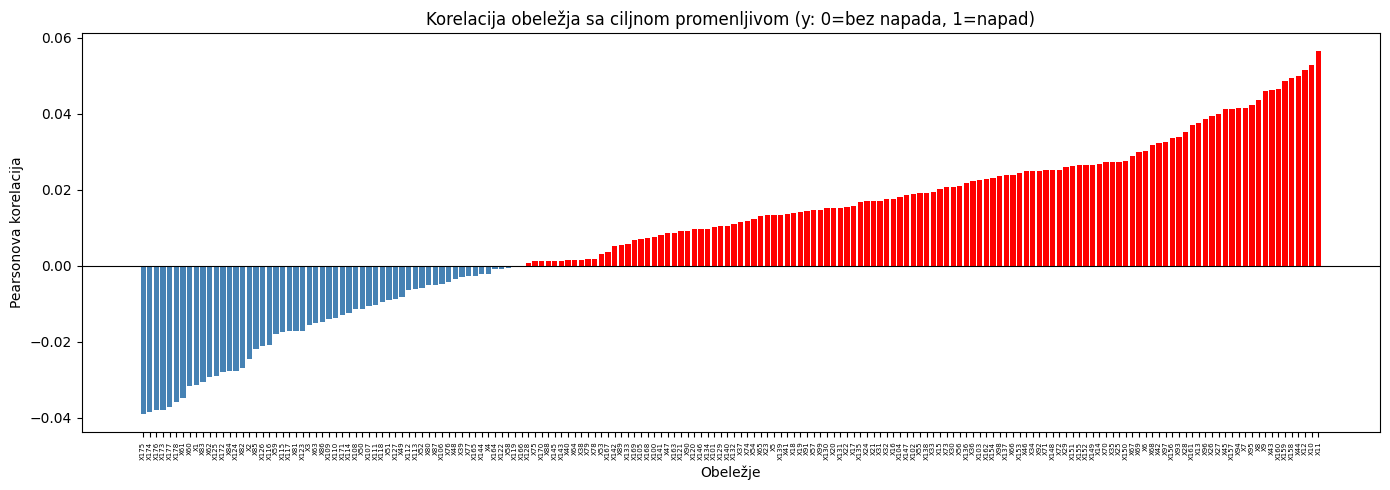

Top 10 obeležja sa najvećom pozitivnom korelacijom sa y:
X11     0.056550
X10     0.052803
X12     0.051614
X44     0.050075
X158    0.049360
X159    0.048567
X160    0.046451
X43     0.046378
X9      0.046100
X8      0.043528

Top 10 obeležja sa najvećom negativnom korelacijom sa y:
X175   -0.038926
X174   -0.038441
X176   -0.037875
X173   -0.037840
X177   -0.037212
X178   -0.035855
X61    -0.034874
X60    -0.031607
X1     -0.031262
X83    -0.030578


In [14]:
# Korelacija svakog obeležja sa ciljnom promenljivom (point-biserial = Pearsonova za binarnu y)
corr_with_target = X.corrwith(y).sort_values()

plt.figure(figsize=(14, 5))
colors = ['red' if v > 0 else 'steelblue' for v in corr_with_target]
plt.bar(corr_with_target.index, corr_with_target.values, color=colors)
plt.title('Korelacija obeležja sa ciljnom promenljivom (y: 0=bez napada, 1=napad)')
plt.xlabel('Obeležje')
plt.ylabel('Pearsonova korelacija')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=90, fontsize=5)
plt.tight_layout()
plt.show()

print("Top 10 obeležja sa najvećom pozitivnom korelacijom sa y:")
print(corr_with_target.sort_values(ascending=False).head(10).to_string())
print("\nTop 10 obeležja sa najvećom negativnom korelacijom sa y:")
print(corr_with_target.head(10).to_string())

Svaki linija prikazuje korelaciju tog obeležja X i ciljne promenljive y. Sve korelacione vrednosti su u odnosu na y=1 (napad). Crvene linije označavaju obeležja sa pozitivnom korelacijom, dok plave linije predstavljaju negativnu korelaciju u odnosu sa targetom, odnosno napadom.

# 8. Analiza kolone 'Unnamed'

In [15]:
# Analiza kolone 'Unnamed'

df = load_data(str(config.DATA_PATH))
df['Unnamed'].head()



0    X21.V1.791
1    X15.V1.924
2       X8.V1.1
3     X16.V1.60
4     X20.V1.54
Name: Unnamed, dtype: str

Podaci u koloni se sastoje od tri segmenta odvojena '.'

In [16]:
# Oblik vrednosti u toj koloni:
# X[broj].V[broj].[broj]
# Tri segmenta odvojena '.'

parts = df['Unnamed'].str.split('.', expand=True)
parts.columns = ['part1', 'part2', 'part3']
df = pd.concat([df, parts], axis=1)

## 8.1. Prvi segment
Format - X[broj]

In [17]:
# Prvi segment X[broj]

df['part1'].value_counts().sort_index()

part1
X1     500
X10    500
X11    500
X12    500
X13    500
X14    500
X15    500
X16    500
X17    500
X18    500
X19    500
X2     500
X20    500
X21    500
X22    500
X23    500
X3     500
X4     500
X5     500
X6     500
X7     500
X8     500
X9     500
Name: count, dtype: int64

In [18]:
df.groupby('part1').size().value_counts()


500    23
Name: count, dtype: int64

**Interpretacija prvog segmenta:**

X1 ... X23 su oznake segmenata
<br>
Svaki ispitanik ima 23 segmenta od po 1 sekundu, dok ukupno ima 500 ispitanika - zato za svaki od segmenata postoji 500 vrednosti


## 8.2. Drugi segment
Format - V[broj]

In [19]:
# Drugi segment V[broj]

df['part2'].value_counts().sort_index()

part2
V1     11408
V11       23
V12       23
V13       23
V14       23
Name: count, dtype: int64

In [20]:
pd.crosstab(df['part2'], df['y'])


y,1,2,3,4,5
part2,,,,,
V1,2277,2277,2277,2277,2300
V11,0,0,0,23,0
V12,0,0,23,0,0
V13,0,23,0,0,0
V14,23,0,0,0,0


**Interpretacija drugog segmenta**

Na osnovu raspodele vrednost iz segmenta 2 zaključujemo da on ne donosi informativnost.
<br>
Mozemo pretpostaviti da proizilazi iz obeležavanja datoteka unutar sistema.

## 8.3. Treći segment
Format - [broj]

In [21]:
# Treći segment [broj]

df['part3'].head()

0    791
1    924
2      1
3     60
4     54
Name: part3, dtype: str

In [22]:
df.groupby('part3').size()

part3
1      23
10     23
101    23
102    23
103    23
       ..
99     23
991    23
992    23
993    23
994    23
Length: 495, dtype: int64

**Interpretacija trećeg segmenta**

Segment 3 ima 495 (skoro 500) jedinstvenih vrednosti, svaka vrednost se ponavlja 23 puta u skupu.
<br>
Segment 3 identifikuje celokupan EEG zapis.



Primećujemo da u određenom delu skupa fali treći segment.

In [23]:
# Koliko redova nema segment 3
num_missing = df['part3'].isna().sum()

# Ukupan broj redova
total_rows = len(df)

# Procenat
percent_missing = (num_missing / total_rows) * 100

print(f"Redova bez trećeg segmenta: {num_missing} / {total_rows} = {percent_missing:.2f}%")

Redova bez trećeg segmenta: 115 / 11500 = 1.00%


Treći segment fali u 1% skupa.

### Segment 3 postaje novo obeležje `recording_id`.

Kada bismo nasumično delili skup podataka (u train/test split), podaci iz jednog zapisa odnosno od jednog pacijenta bi mogli da završe u različitim skupovima.
<br><br>
Ideja: Napraviti train/test split sa grupisanjem po `recording_id` tako da nema leakage-a.

U nastavku se formira nova kolona `recording_id`, na osnovu koje ćemo podatke deliti u train, validation i test skupove.
<br>
Uklanjaju se redovi koji nemaju segment 3.


In [24]:
# prepare_data koristi extract_parts iz src.data
df = load_data(str(config.DATA_PATH))
df_clean, X, y, groups = prepare_data(df)


# **II Priprema podataka**

# 1. Podela skupa podataka za trening, validaciju i test

Podaci sadrže i ``recording_id`` kako bi se uspešno delili prema EEG segmentima. ``recording_id`` će se ukloniti nakon podele.



## 1.1. Train/Test/Validation split, bez data leakeage

Podela na trening (70%), validacioni (15%) i test skup (15%).

Segmenti jednog EEG napisa nalaze se isključivo u jednom od skupova.

In [25]:
X_train, X_val, X_test, y_train, y_val, y_test, split_info = split_data(
    X, y, groups,
    test_size=config.TEST_SIZE,
    val_size=config.VAL_SIZE,
    random_state=config.RANDOM_STATE,
)

print("Broj trening uzoraka:", len(X_train))
print("Broj validation uzoraka:", len(X_val))
print("Broj test uzoraka:", len(X_test))


Broj trening uzoraka: 7958
Broj validation uzoraka: 1702
Broj test uzoraka: 1725


## 1.2. Provera da je izbegnut data leakage

In [26]:
# Provera da li ima preklapanja recording_id između train i test
train_groups = split_info['train_groups']
val_groups = split_info['val_groups']
test_groups = split_info['test_groups']

print("Preklapanje train/val:", train_groups & val_groups)
print("Preklapanje train/test:", train_groups & test_groups)
print("Preklapanje val/test:", val_groups & test_groups)
# set() znaci da je prazan skup - set=skup

print("\nBroj jedinstvenih recording_id u trening skupu:", len(train_groups))
print("Broj jedinstvenih recording_id u validacionom skupu:", len(val_groups))
print("Broj jedinstvenih recording_id u test skupu:", len(test_groups))


Preklapanje train/val: set()
Preklapanje train/test: set()
Preklapanje val/test: set()

Broj jedinstvenih recording_id u trening skupu: 346
Broj jedinstvenih recording_id u validacionom skupu: 74
Broj jedinstvenih recording_id u test skupu: 75


Svi segmenti koji imaju isti ``recording id`` se nalaze u jednom od tri skupa (skupovi su nepreklapajući).

# 2. Standardizacija (normalizacija) podataka StandarScaler funkcijom

StandardScaler radi tako što izračunava srednju vrednost i standardnu devijaciju za svaku kolonu (feature). Ova faza se zove fit() i primenjuje se samo na trening skupu podataka. Potom, scaler koristi naučene statističke vrednosti iz trening skupa i vrši transformaciju sva tri skupa (trening, validacioni i test), uz pomoć funkcije transform().

Na ovaj način se takođe sprečava pojava curenja podataka iz trening skupa u validacioni i test skup tokom procesa standardizacije.

In [27]:
feature_columns_before_scaling = X_train.columns
X_train_scaled, X_val_scaled, X_test_scaled = scale_data(X_train, X_val, X_test)
X_train = X_train_scaled
X_val = X_val_scaled
X_test = X_test_scaled

## 2.1. Provera uspešnosti StandardScaler-a

In [28]:
verify_scaling(X_train, X_val, X_test, feature_columns_before_scaling, sample_columns=['X1', 'X30', 'X60'])


--- Statistika za skup X_train_scaled ---
  X1: Mean = 0.0000, Std = 1.0000
  X30: Mean = 0.0000, Std = 1.0000
  X60: Mean = 0.0000, Std = 1.0000

--- Statistika za skup X_val_scaled ---
  X1: Mean = -0.0168, Std = 1.2165
  X30: Mean = 0.0031, Std = 1.2482
  X60: Mean = 0.0374, Std = 1.2105

--- Statistika za skup X_test_scaled ---
  X1: Mean = -0.0158, Std = 0.9057
  X30: Mean = -0.0138, Std = 1.0223
  X60: Mean = -0.0245, Std = 0.9597


Obeležja trening skupa nakon primene standardizacije imaju srednju vrednost 0, a standardnu devijaciju 1, što je i očekivano jer se StandardScaler trenira upravo na ovim podacima da postigne te vrednosti.

Srednje vrednosti su blizu 0, a standardne devijacije blizu 1, za podatke iz validacionih i test skupova.
<br>
Razlike u vrednostima u odnosu na trening skup ukazuju na prirodne varijacije u distribuciji podataka između skupova.
<br>
Razlike se javljaju iz razloga što se na validacione i test skupove primenjuju parametri skaliranja naučeni isključivo iz trenirajućeg skupa, tako da je sprečen data leakage.